In [1]:
import numpy as np

def generate_dataset(n_samples_per_cluster=100,
                     length=16,
                     noise_std=0.05,
                     seed=42):

    rng = np.random.default_rng(seed)

    # Curvas base
    low = np.linspace(0.2, 0.4, length)
    high = np.linspace(0.6, 0.8, length)

    X_timbre = []
    X_phase = []
    y = []

    clusters = [
        (low,  low,  0),
        (high, high, 0),
        (low,  high, 1),
        (high, low,  1),
    ]

    for timbre_base, phase_base, label in clusters:

        for _ in range(n_samples_per_cluster):

            timbre = timbre_base + rng.normal(0, noise_std, length)
            phase  = phase_base  + rng.normal(0, noise_std, length)

            timbre = np.clip(timbre, 0, 1)
            phase  = np.clip(phase, 0, 1)

            X_timbre.append(timbre)
            X_phase.append(phase)
            y.append(label)

    return np.array(X_timbre), np.array(X_phase), np.array(y)

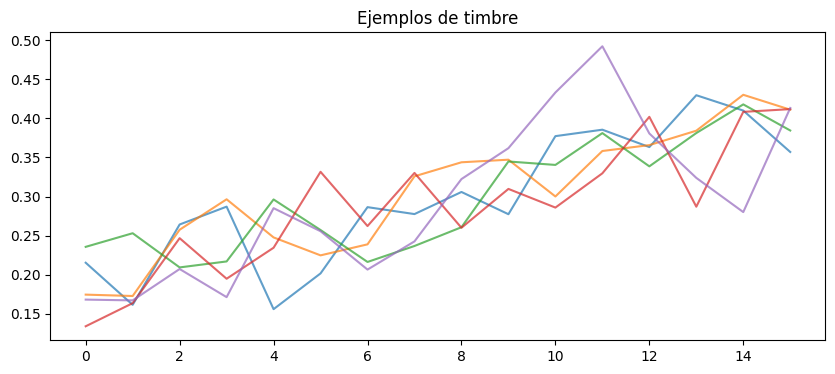

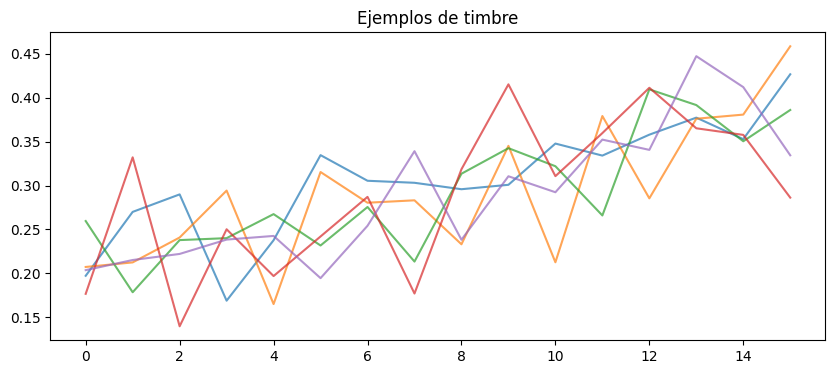

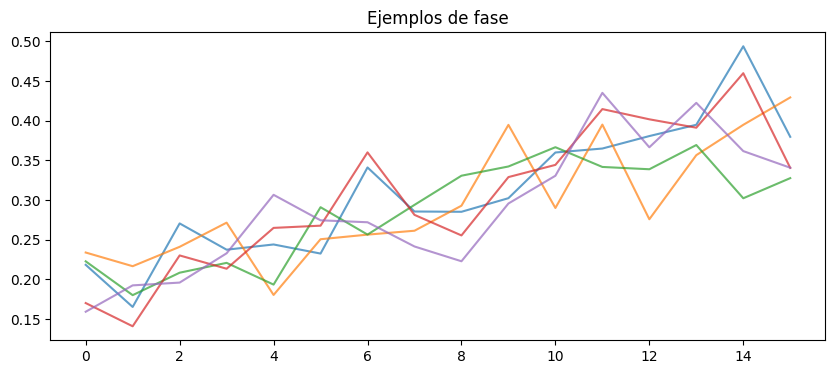

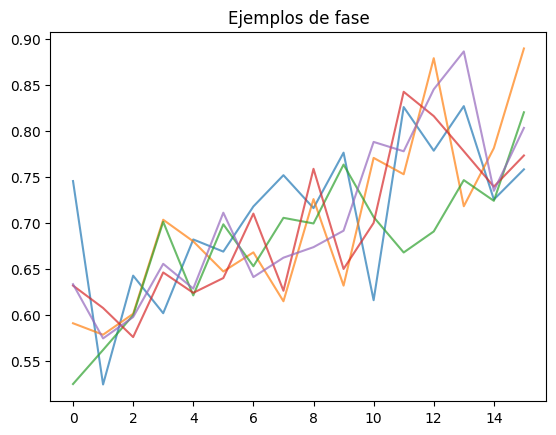

In [2]:
import matplotlib.pyplot as plt

Xt, Xp, y = generate_dataset(n_samples_per_cluster=25)

plt.figure(figsize=(10,4))

for i in range(5):
    plt.plot(Xt[i], alpha=0.7)

plt.title("Ejemplos de timbre")
plt.show()

plt.figure(figsize=(10,4))

for i in range(50,55):
    plt.plot(Xt[i], alpha=0.7)

plt.title("Ejemplos de timbre")
plt.show()

plt.figure(figsize=(10,4))

for i in range(5):
    plt.plot(Xp[i], alpha=0.7)

plt.title("Ejemplos de fase")
plt.show()

for i in range(50,55):
    plt.plot(Xp[i], alpha=0.7)

plt.title("Ejemplos de fase")
plt.show()

In [3]:
from sklearn.model_selection import train_test_split

# Test = 20%
X_trainval_t, X_test_t, X_trainval_p, X_test_p, y_trainval, y_test = train_test_split(
    Xt,
    Xp,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# Del 80% restante:
# train = 80% de ese 80% = 64% total
# val   = 20% de ese 80% = 16% total
X_train_t, X_val_t, X_train_p, X_val_p, y_train, y_val = train_test_split(
    X_trainval_t,
    X_trainval_p,
    y_trainval,
    test_size=0.20,
    stratify=y_trainval,
    random_state=42
)

In [4]:
print(X_train_t.shape)
print(X_val_t.shape)
print(X_test_t.shape)

print(y_train.shape)
print(y_val.shape)
print(y_test.shape)

(64, 16)
(16, 16)
(20, 16)
(64,)
(16,)
(20,)


In [5]:
from kernel import get_kernel_matrix
from svm import svm_classification, svm_classic_kernel
from preprozesaketa import preprocess, normalize
from datuak_kargatu import load_audios

def pipeline_cluster(encoding=None):

    w=None
    b=None

    K_train = get_kernel_matrix(X_train_t, feature_map=encoding,w=w,b=b, X1_p=X_train_p, train=False)
    K_test = get_kernel_matrix(X_test_t, feature_map=encoding,w=w,b=b, X2=X_train_t, X1_p=X_test_p, X2_p=X_train_p, train=False)


    final_acc, final_auc, final_f1 = svm_classification(K_train,y_train,K_test,y_test)

    print("FINAL ACC: ", final_acc)
    print("FINAL AUC: ", final_auc)
    print("FINAL F1: ", final_f1)

    return final_acc, final_auc, final_f1

In [7]:
acc, auc, f1 = pipeline_cluster(encoding="qtse_p3")

Y pred:  [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
FINAL ACC:  0.5
FINAL AUC:  0.5
FINAL F1:  0.6666666666666666


In [20]:
from sklearn.svm import SVC

clf = SVC(kernel="rbf")
clf.fit(X_train_t, y_train)

print(clf.score(X_test_t, y_test))

0.5


In [21]:
X_train = np.hstack([X_train_t, X_train_p])
X_test = np.hstack([X_test_t, X_test_p])

clf = SVC(kernel="rbf")
clf.fit(X_train, y_train)

print(clf.score(X_test, y_test))

1.0


In [1]:
from preprozesaketa import preprocess
import numpy as np
from datuak_kargatu import load_audios

dataset_path="./data/prep/64_16_20/classical_rock"

X = np.load(dataset_path + "/X.npy", allow_pickle=True)
y = np.load(dataset_path + "/y.npy")
folds = np.load(dataset_path + "/folds.npy", allow_pickle=True)

fold_i = 0

fold = folds[fold_i]

X_train_paths = X[fold["train"]]
X_val_paths   = X[fold["val"]]
X_test_paths  = X[fold["test"]]

y_train = y[fold["train"]]
y_val   = y[fold["val"]]
y_test  = y[fold["test"]]

# cargar audios
X_train = load_audios(X_train_paths)
X_val   = load_audios(X_val_paths)
X_test  = load_audios(X_test_paths)

X_train_t = preprocess(X_train,type="if",classic=True)

/home/iri/Documents/Uni4/Praktikak_TFG/Phase-Sensitive-Quantum-Time-Series-Encoding-For-Audio-Classification-And-Geometric-Analysis-main/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
print(X_train_t[0].shape)

(661498,)


In [ ]:
from kodeketak import draw_circuit,ry_rz_1, qtse

t = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]
a = [4,7,3,5,6,6,7,7,2,1,1,1,1,1,1,1]
p = [2,5,1,1,1,1,1,1,1,1,1,1,1,1,1,1]

qc = qtse(a)
draw_circuit(qc,save_path="circuits/qtse_proba.png")


Circuit saved to circuits/ryrz_proba.png
